# Task 3: Clustering Analysis (KMeans)

## 1. Importing the required libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 2. Loading of cleaned dataset

In [21]:
aapl = pd.read_csv("cleaned_stock_prices-copy1.csv")

In [22]:
# Converting date column to datetime

aapl['date'] = pd.to_datetime(aapl['date'])

In [23]:
# Displaying basic information

print("Dataset shape:", aapl.shape)

print("\nColumns:")
print(aapl.columns.tolist())

print("\nFirst 5 rows:")
display(aapl.head())

Dataset shape: (497472, 7)

Columns:
['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']

First 5 rows:


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


## 3. Inspecting the Data before clustering

In [9]:
print("Number of rows:", len(aapl))
print("Number of columns:", len(aapl.columns))

print("\nColumn data types:")
print(aapl.dtypes)

print("\nNumber of unique stocks:", aapl['symbol'].nunique())

print("\nDate range:")
print(aapl['date'].min(), "to", aapl['date'].max())

Number of rows: 497472
Number of columns: 7

Column data types:
symbol               str
date      datetime64[us]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

Number of unique stocks: 505

Date range:
2014-01-02 00:00:00 to 2017-12-29 00:00:00


## 4. Selecting the clustering features

In [10]:
# Creating stock-level features

stock_features = aapl.groupby('symbol').agg(
    avg_open=('open', 'mean'),
    avg_high=('high', 'mean'),
    avg_low=('low', 'mean'),
    avg_close=('close', 'mean'),
    avg_volume=('volume', 'mean')
).reset_index()

# Displaying the result

print("Number of stocks:", len(stock_features))
print("Number of features:", len(stock_features.columns) - 1)

display(stock_features.head())

Number of stocks: 505
Number of features: 5


,symbol,avg_open,avg_high,avg_low,avg_close,avg_volume
0,A,49.085571,49.485352,48.680860,49.097726,2.191932e+06
1,AAL,42.420103,43.037743,41.799285,42.424900,9.751521e+06
2,AAP,143.205079,144.716834,141.663015,143.187120,1.137307e+06
3,AAPL,116.811396,117.747015,115.856082,116.839892,4.516957e+07
4,ABBV,63.296754,63.960244,62.651796,63.338302,8.408836e+06


## 5. Standardizing the features

In [11]:
# Selecting numerical features

cluster_features = [
    'avg_open',
    'avg_high',
    'avg_low',
    'avg_close',
    'avg_volume']

X = stock_features[cluster_features]

# Standardizing the features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# Checking the result

print("Original data shape:", X.shape)
print("Standardized data shape:", X_scaled.shape)

print("\nFirst 5 standardized rows:")
print(X_scaled[:5])

Original data shape: (505, 5)
Standardized data shape: (505, 5)

First 5 standardized rows:
[[-0.37910462 -0.37969084 -0.37856519 -0.37913396 -0.30734028]
 [-0.44791628 -0.4456811  -0.45027116 -0.44802047  0.82555362]
 [ 0.59254802  0.59498834  0.59030833  0.59219218 -0.46538829]
 [ 0.32007006  0.3189565   0.32140023  0.32019818  6.13336719]
 [-0.23239398 -0.2315426  -0.23298812 -0.23212224  0.62433636]]


## 6. The Elbow Method

In [12]:
# Determining the optimal number of clusters using the Elbow Method

inertia = []

# Testing K values from 2 to 10
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Displaying the inertia values

for k, value in zip(k_values, inertia):
    print(f"K = {k}: Inertia = {value:.2f}")

K = 2: Inertia = 1316.81
K = 3: Inertia = 937.32
K = 4: Inertia = 631.46
K = 5: Inertia = 425.52
K = 6: Inertia = 320.80
K = 7: Inertia = 242.31
K = 8: Inertia = 186.16
K = 9: Inertia = 137.48
K = 10: Inertia = 110.44


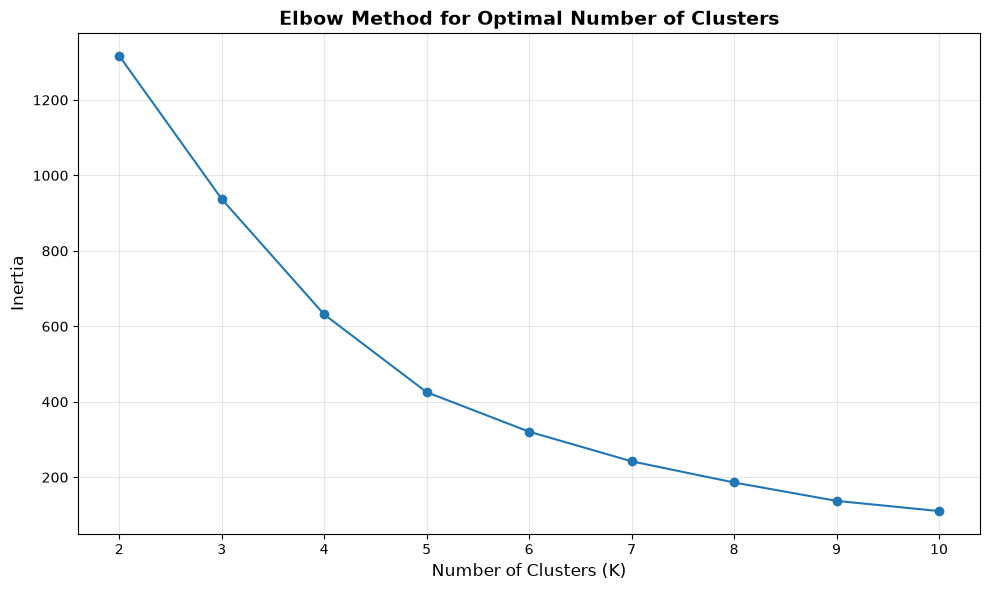

In [13]:
# Plotting the Elbow Method

plt.figure(figsize=(10, 6))

plt.plot(k_values, inertia, marker='o')

plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method for Optimal Number of Clusters', fontsize=14, fontweight='bold')

plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Observation: The elbow plot shows a clear bend around K = 5–6,

## 7. Applying K-Means Clustering

The actual K-Means model will be created  using 5 clusters.

In [14]:
# Apply K-Means clustering

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10)

# Fitting the model to the standardized data
cluster_labels = kmeans.fit_predict(X_scaled)

# Addding cluster labels to our stock-level dataset
stock_features['cluster'] = cluster_labels

# Checking the result
print("K-Means clustering completed successfully.")

print("\nCluster labels for the first 10 stocks:")
print(stock_features[['symbol', 'cluster']].head(10))

K-Means clustering completed successfully.

Cluster labels for the first 10 stocks:
  symbol  cluster
0      A        0
1    AAL        0
2    AAP        4
3   AAPL        2
4   ABBV        0
5    ABC        0
6    ABT        0
7    ACN        4
8   ADBE        0
9    ADI        0


## 8. Counting stocks in each cluster

In [15]:
cluster_counts = stock_features['cluster'].value_counts().sort_index()

print("Number of stocks in each cluster:")
print(cluster_counts)

Number of stocks in each cluster:
cluster
0    374
1      8
2     16
3      1
4    106
Name: count, dtype: int64


## 8.1 Visualizing the cluster distribution

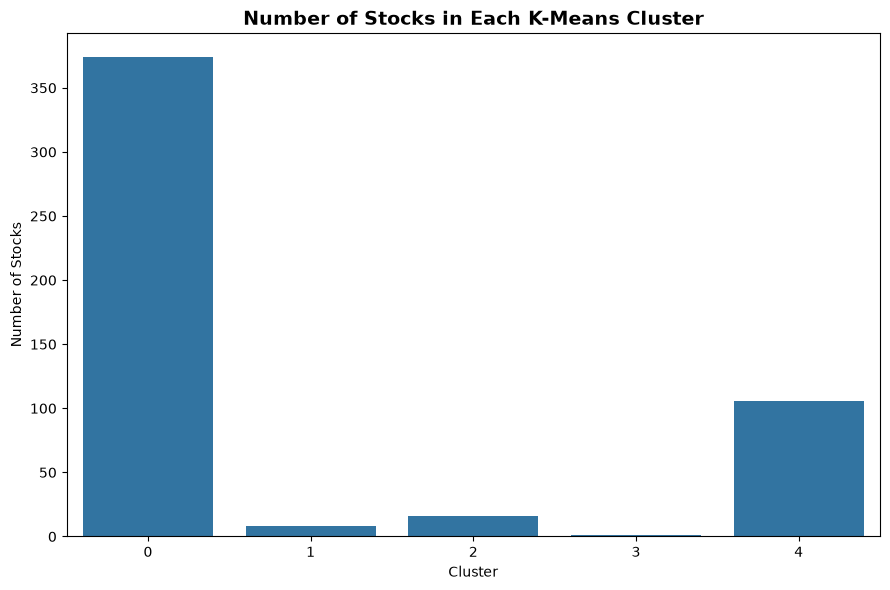

In [16]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values)

plt.title('Number of Stocks in Each K-Means Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Stocks')

plt.tight_layout()
plt.show()

## 9. Seeing the clusters visually

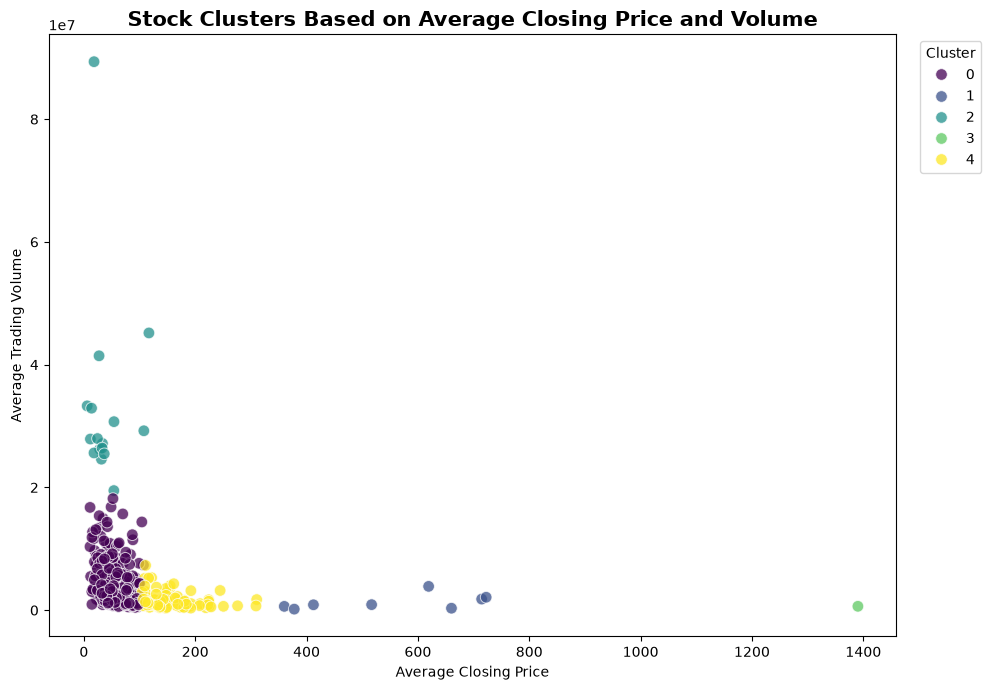

In [17]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=stock_features,
    x='avg_close',
    y='avg_volume',
    hue='cluster',
    palette='viridis',
    s=70,
    alpha=0.75
)

plt.title('Stock Clusters Based on Average Closing Price and Volume',
          fontsize=15, fontweight='bold')

plt.xlabel('Average Closing Price')
plt.ylabel('Average Trading Volume')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 9. Interpretation of the 2D Cluster Plot

The scatter plot shows that the 505 stocks are separated into five distinct groups based on their average closing prices and average trading volumes.

- Cluster 0 (374 stocks) is the dominant group. These stocks generally have relatively similar average price and trading-volume characteristics and form the main concentration of the dataset.
- Cluster 4 (106 stocks) forms the second-largest group. These stocks have characteristics that distinguish them from the large Cluster 0, particularly in their average price and/or trading volume.
- Cluster 2 (16 stocks) represents a much smaller group of stocks with more unusual combinations of price and volume.
- Cluster 1 (8 stocks) is another small, relatively distinct group.
- Cluster 3 (1 stock) is the most unusual cluster. The fact that K-Means isolated only one stock indicates that its price/volume profile is substantially different from the other stocks.
  
## What the visualization tells us

The important point is that stock price and trading volume are not distributed uniformly across the 505 stocks. K-Means has identified groups of stocks with similar characteristics and separated stocks with considerably different profiles.

The very small Clusters 1, 2, and especially 3 can be viewed as groups containing more distinctive observations rather than simply being errors or problems with the analysis.

However, remember that our model uses average Open, High, Low, Close, and Volume. Therefore, these clusters describe stocks according to their overall price and trading-volume levels, not their investment performance, returns, or volatility.

## What actually characterizes each cluster?

Lets calculate the average values of Open, High, Low, Close, and Volume for each cluster.

In [18]:
cluster_summary = (
    stock_features
    .groupby('cluster')[cluster_features]
    .mean()
    .round(2)
)

print("Average characteristics of each cluster:")
display(cluster_summary)

Average characteristics of each cluster:


,avg_open,avg_high,avg_low,avg_close,avg_volume
cluster,,,,,
0,56.88,57.41,56.35,56.89,3808395.11
1,547.96,552.85,542.72,547.94,1336433.83
2,38.43,38.77,38.07,38.44,33311617.13
3,1390.18,1402.19,1377.43,1390.27,632928.23
4,147.83,149.15,146.49,147.87,1640959.47


## Observation: 
The clustering analysis successfully identified five groups of stocks with different price and trading-volume characteristics.

The strongest distinction is between:

Lower-priced/high-volume stocks → Cluster 2
Typical stocks → Cluster 0
Higher-priced stocks → Clusters 4 and 1
Extremely high-priced stock → Cluster 3

# Finally

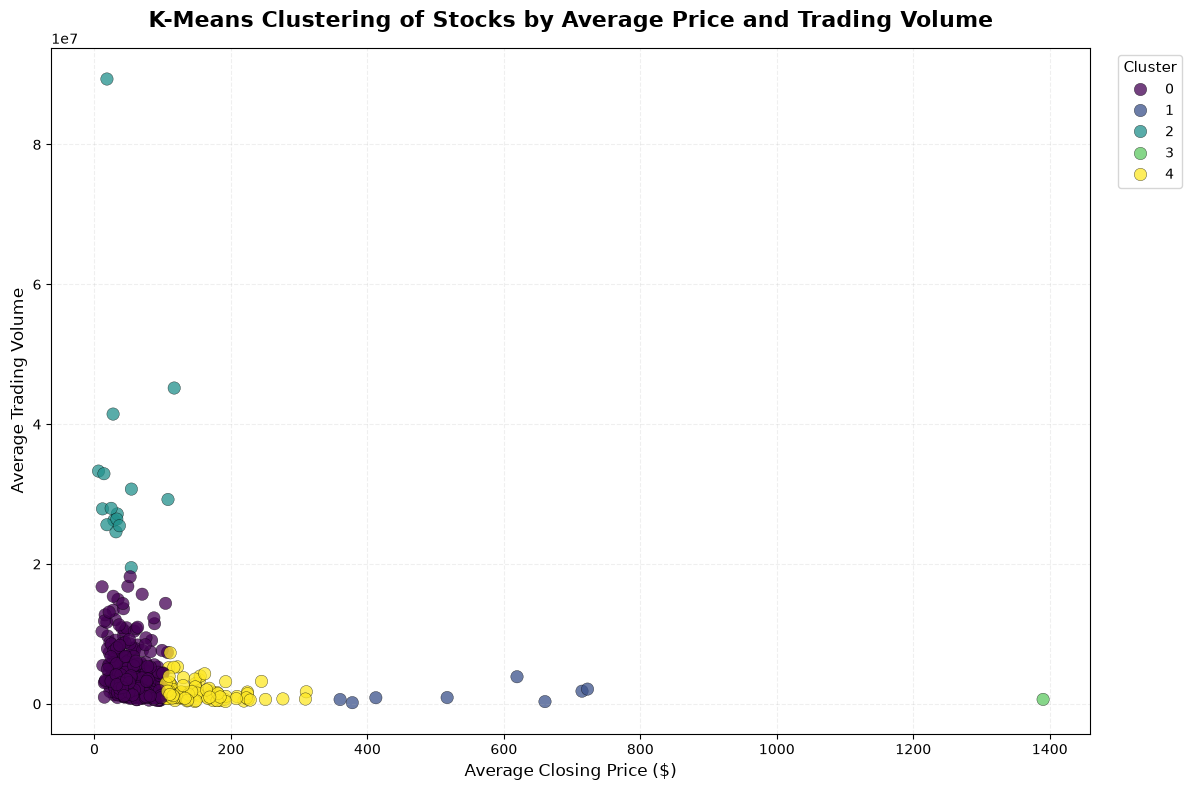

In [19]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=stock_features,
    x='avg_close',
    y='avg_volume',
    hue='cluster',
    palette='viridis',
    s=80,
    alpha=0.75,
    edgecolor='black',
    linewidth=0.3
)

plt.title(
    'K-Means Clustering of Stocks by Average Price and Trading Volume',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Average Closing Price ($)', fontsize=12)
plt.ylabel('Average Trading Volume', fontsize=12)

plt.legend(
    title='Cluster',
    title_fontsize=11,
    fontsize=10,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(alpha=0.2, linestyle='--')
plt.tight_layout()

plt.savefig(
    'stock_kmeans_clusters.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Clustering Analysis Conclusion

The clustering analysis was successfully completed using the K-Means algorithm on the cleaned stock price dataset. The data was first aggregated at the stock level to obtain average Open, High, Low, Close, and Trading Volume values for each of the 505 stocks. These features were standardized using `StandardScaler` to ensure that variables with larger numerical values did not disproportionately influence the clustering process.

The Elbow Method was then used to determine an appropriate number of clusters. Based on the reduction in inertia and the point where the improvement began to slow, **5 clusters** were selected. K-Means was subsequently applied with five clusters, producing five distinct groups containing **374, 8, 16, 1, and 106 stocks**, respectively.

The cluster analysis revealed meaningful differences in stock characteristics. The largest cluster represented stocks with relatively moderate prices and trading volumes, while another cluster contained lower-priced stocks with exceptionally high trading volumes. Other clusters consisted of progressively higher-priced stocks, with one single-stock cluster representing an extreme high-price profile. The 2D scatter plot provided a visual representation of these differences and confirmed that the algorithm identified distinct patterns within the dataset.

Overall, the analysis demonstrates how **unsupervised machine learning can be used to discover natural groupings within financial data without predefined labels**. The resulting clusters provide useful insight into similarities and differences among stocks based on their historical price levels and trading activity.
